# 10. Full Industrial Symbiosis

This final model closes every loop opened across the series into a single site: electricity, heat,
hydrogen, ammonia, and methanol, plus a waste-biomass stream valorized through pyrolysis. It's the
masterclass model — not because any single component is new, but because *everything* interacts:
waste heat that was previously discarded now has somewhere useful to go, and a waste stream (biomass)
becomes a feedstock instead of a disposal cost.

The objective is to combine every component built across Models 01-09 into one network, and add two
new heat-recovery pathways: **waste heat capture from the electrolyzer, Haber-Bosch, and methanol
synthesis reactions** (all previously vented, now injected into `heat_bus`), and a **pyrolysis unit**
that converts a capped waste-biomass stream into heat and a saleable biochar byproduct.

## 🛠️ System Topology
1. **Buses:** `electricity_bus`, `heat_bus`, `hydrogen_bus`, `nitrogen_bus`, `co2_bus`,
   `ammonia_bus`, `methanol_bus` (all from Models 01-09), plus two new mass-flow buses:
   `biomass_bus` and `biochar_bus`.
2. **Generators (Source):** Solar PV, Wind, `Grid_Import`, `N2_Source`, `CO2_Source` (all unchanged),
   plus a new `Biomass_Feedstock` — a capped, cheap (waste) supply of biomass, priced with a small
   **negative** cost to represent an avoided disposal/tipping fee.
3. **Generators (Sink):** `Grid_Export`, `Ammonia_Market`, `Methanol_Market` (unchanged), plus a new
   `Heat_Market` (sells surplus district heat externally) and `Biochar_Market` (sells the pyrolysis
   byproduct).
4. **Loads:** `Industrial_Load`, `Heat_Demand`, `H2_Demand` (all unchanged).
5. **Storage:** `Battery`, `Thermal_Storage`, `Hydrogen_Storage` (all unchanged; `Thermal_Storage`
   capacity increased slightly to buffer the additional waste-heat inflows).
6. **Links:** `Heat_Pump`, `Electric_Boiler` (unchanged). `Electrolyzer`, `Haber_Bosch`, and
   `Methanol_Synthesis` each gain an **extra output bus onto `heat_bus`**, capturing the waste heat
   their reactions already produce. A new `Pyrolysis` link converts biomass into heat (main product)
   and biochar (byproduct).

### The symbiosis, end to end
Waste heat from hydrogen and chemical production, plus heat recovered from a biomass waste stream,
now all land on the same `heat_bus` as the heat pump and boiler. `Thermal_Storage` buffers all of it
against the district heating demand, and anything genuinely surplus is sold to `Heat_Market` instead
of being vented — turning three previously wasted energy streams into one coordinated heat supply.

<img src="../assets/model_10.jpg" alt="Model 10 System Topology" width="800">


In [13]:
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys

sys.path.append('../')
from utils.viz_utils import set_nature_style
set_nature_style()

df_pv = pd.read_csv('../data/processed/pv_2025_hourly.csv', index_col='time', parse_dates=True)
df_wind = pd.read_csv('../data/processed/wind_2025_hourly.csv', index_col='time', parse_dates=True)
df_price = pd.read_csv('../data/processed/electricity_price_2025_hourly.csv', index_col='time', parse_dates=True)

perfect_index = pd.date_range(start='2025-01-01 00:00', end='2025-12-31 23:00', freq='1h')
df_pv.index = perfect_index
df_wind.index = perfect_index
df_price.index = perfect_index

df_pv['capacity_factor'] = df_pv['pv_generation_kw'].clip(upper=1.0)
df_wind['capacity_factor'] = df_wind['wind_generation_kw'].clip(upper=1.0)


## ⚙️ Technical Parameters

Every parameter from Models 08-09 is carried over unchanged. Three new entries are added: waste-heat
recovery fractions for the electrolyzer and the two synthesis reactors, and the pyrolysis unit's
conversion factors.


In [14]:
H2_LHV_MWH_PER_TONNE = 33.33

h2_per_tonne_nh3 = (3 * 2) / (2 * 17)
n2_per_tonne_nh3 = 28 / (2 * 17)
h2_mwh_per_tonne_nh3 = h2_per_tonne_nh3 * H2_LHV_MWH_PER_TONNE

h2_per_tonne_meoh = 6 / 32
co2_per_tonne_meoh = 44 / 32
h2_mwh_per_tonne_meoh = h2_per_tonne_meoh * H2_LHV_MWH_PER_TONNE

tech_param = {
    'solar_pv': {'p_nom': 10.0, 'marginal_cost': 0.0},
    'wind': {'p_nom': 15.0, 'marginal_cost': 0.0},
    'market_grid': {'import_p_nom': 20.0, 'export_p_nom': 18.0},
    'demand': {'day_load_mw': 8.0, 'night_load_mw': 4.0},
    'battery': {'p_nom': 4.0, 'max_hours': 2.0, 'efficiency_store': 0.95, 'efficiency_dispatch': 0.95},
    'heat_pump': {'p_nom': 1.0, 'cop': 3.5, 'marginal_cost': 0.5},
    'electric_boiler': {'p_nom': 5.0, 'efficiency': 0.99, 'marginal_cost': 1.0},
    'heat_demand': {'avg_mw': 3.0, 'amplitude_mw': 2.0},
    'thermal_storage': {'e_nom': 60.0, 'standing_loss': 0.01},   # increased vs. Model 06-09
    'electrolyzer': {
        'p_nom': 6.0, 'efficiency': 0.65, 'marginal_cost': 0.0,
        'heat_recovery_fraction': 0.15    # NEW: fraction of electrical input recovered as waste heat
    },
    'hydrogen_storage': {'e_nom': 20.0, 'standing_loss': 0.0},
    'h2_demand': {'avg_mw': 1.5},
    'haber_bosch': {
        'p_nom': 2.0,
        'efficiency': 1 / h2_mwh_per_tonne_nh3,
        'efficiency2': -n2_per_tonne_nh3 / h2_mwh_per_tonne_nh3,
        'heat_recovery_fraction': 0.10    # NEW: fraction of H2 input energy recovered as waste heat
    },
    'methanol_synthesis': {
        'p_nom': 2.0,
        'efficiency': 1 / h2_mwh_per_tonne_meoh,
        'efficiency2': -co2_per_tonne_meoh / h2_mwh_per_tonne_meoh,
        'heat_recovery_fraction': 0.08    # NEW
    },
    'feedstock_price': {'n2_eur_per_tonne': 20.0, 'co2_eur_per_tonne': 60.0},
    'product_price': {'nh3_eur_per_tonne': 500.0, 'meoh_eur_per_tonne': 550.0},
    'pyrolysis': {
        'p_nom': 2.0,                  # Max biomass input rating, tonnes/h
        'heat_mwh_per_tonne': 2.0,      # Heat recovered per tonne biomass processed
        'biochar_t_per_tonne': 0.30     # Biochar byproduct per tonne biomass processed
    },
    'biomass_feedstock': {
        'p_nom': 2.0,                   # Capped waste-biomass availability, tonnes/h
        'tipping_fee_eur_per_tonne': -10.0  # Negative cost = paid to take the waste
    },
    'biochar_price_eur_per_tonne': 150.0,
    'dh_market_price_eur_per_mwh': 30.0
}


## 🏗️ Initializing the Network

Nine buses in total: the seven carried over from Models 08-09, plus `biomass_bus` and `biochar_bus`
for the new pyrolysis pathway.


In [15]:
n = pypsa.Network()
n.set_snapshots(df_pv.index)

n.add("Bus", "electricity_bus")
n.add("Bus", "heat_bus")
n.add("Bus", "hydrogen_bus")
n.add("Bus", "nitrogen_bus")
n.add("Bus", "co2_bus")
n.add("Bus", "ammonia_bus")
n.add("Bus", "methanol_bus")
n.add("Bus", "biomass_bus")
n.add("Bus", "biochar_bus")


Index(['biochar_bus'], dtype='object')

## ⚡ Adding Generators and the Grid Connection

Solar, Wind, `Grid_Import`, and `Grid_Export` are unchanged from Models 08-09.


In [16]:
n.add("Generator", "Solar_PV", bus="electricity_bus",
      p_nom=tech_param['solar_pv']['p_nom'], p_max_pu=df_pv['capacity_factor'],
      marginal_cost=tech_param['solar_pv']['marginal_cost'])

n.add("Generator", "Wind", bus="electricity_bus",
      p_nom=tech_param['wind']['p_nom'], p_max_pu=df_wind['capacity_factor'],
      marginal_cost=tech_param['wind']['marginal_cost'])

n.add("Generator", "Grid_Import", bus="electricity_bus",
      p_nom=tech_param['market_grid']['import_p_nom'], marginal_cost=df_price['price'])

n.add("Generator", "Grid_Export", bus="electricity_bus",
      p_nom=tech_param['market_grid']['export_p_nom'],
      p_min_pu=-1.0, p_max_pu=0.0, marginal_cost=df_price['price'])


Index(['Grid_Export'], dtype='object')

## 🎯 Adding the Electrical, Heat, and Hydrogen Demands

Unchanged from Models 05-09.


In [17]:
is_daytime = (n.snapshots.hour >= 8) & (n.snapshots.hour < 18)
electrical_load = np.where(is_daytime, tech_param['demand']['day_load_mw'], tech_param['demand']['night_load_mw'])
electrical_load = pd.Series(electrical_load, index=n.snapshots)
n.add("Load", "Industrial_Load", bus="electricity_bus", p_set=electrical_load)

day_of_year = n.snapshots.dayofyear
heat_load = tech_param['heat_demand']['avg_mw'] - tech_param['heat_demand']['amplitude_mw'] * np.sin(
    (day_of_year - 80) * 2 * np.pi / 365
)
heat_load = pd.Series(np.clip(heat_load, 0.2, None), index=n.snapshots)
n.add("Load", "Heat_Demand", bus="heat_bus", p_set=heat_load)

h2_load = pd.Series(tech_param['h2_demand']['avg_mw'], index=n.snapshots)
n.add("Load", "H2_Demand", bus="hydrogen_bus", p_set=h2_load)


Index(['H2_Demand'], dtype='object')

## 🔋 Adding Storage, Heat Pump, and Boiler

Unchanged from Models 05-09, other than `Thermal_Storage`'s slightly larger capacity.


In [18]:
n.add("StorageUnit", "Battery", bus="electricity_bus",
      p_nom=tech_param['battery']['p_nom'], max_hours=tech_param['battery']['max_hours'],
      efficiency_store=tech_param['battery']['efficiency_store'],
      efficiency_dispatch=tech_param['battery']['efficiency_dispatch'],
      cyclic_state_of_charge=True)

n.add("Store", "Thermal_Storage", bus="heat_bus",
      e_nom=tech_param['thermal_storage']['e_nom'], e_cyclic=True,
      standing_loss=tech_param['thermal_storage']['standing_loss'])

n.add("Link", "Heat_Pump", bus0="electricity_bus", bus1="heat_bus",
      p_nom=tech_param['heat_pump']['p_nom'], efficiency=tech_param['heat_pump']['cop'],
      marginal_cost=tech_param['heat_pump']['marginal_cost'])

n.add("Link", "Electric_Boiler", bus0="electricity_bus", bus1="heat_bus",
      p_nom=tech_param['electric_boiler']['p_nom'], efficiency=tech_param['electric_boiler']['efficiency'],
      marginal_cost=tech_param['electric_boiler']['marginal_cost'])


Index(['Electric_Boiler'], dtype='object')

## 💧 Adding the Electrolyzer, with Waste Heat Recovery

The electrolyzer now gains a third bus: `bus2="heat_bus"`, with a **positive** `efficiency2` equal to
its assumed waste-heat recovery fraction. This is structurally the same idea used for
`Grid_Export`'s negative-cost trick and `Haber_Bosch`'s negative-input trick — a single link, three
buses, three fixed ratios, all set by the sign and magnitude of each `efficiency` term.


In [19]:
n.add("Link", "Electrolyzer",
      bus0="electricity_bus", bus1="hydrogen_bus", bus2="heat_bus",
      p_nom=tech_param['electrolyzer']['p_nom'],
      efficiency=tech_param['electrolyzer']['efficiency'],
      efficiency2=tech_param['electrolyzer']['heat_recovery_fraction'],
      marginal_cost=tech_param['electrolyzer']['marginal_cost'])

n.add("Store", "Hydrogen_Storage", bus="hydrogen_bus",
      e_nom=tech_param['hydrogen_storage']['e_nom'], e_cyclic=True,
      standing_loss=tech_param['hydrogen_storage']['standing_loss'])


Index(['Hydrogen_Storage'], dtype='object')

## 🧪 Adding Haber-Bosch and Methanol Synthesis, with Waste Heat Recovery

Both reactors now use **all four link buses**: `bus0` (hydrogen in), `bus1` (product out), `bus2`
(secondary feedstock, consumed), and a new `bus3="heat_bus"` (waste heat recovered from the
exothermic reaction, produced).


In [20]:
n.add("Generator", "N2_Source", bus="nitrogen_bus",
      p_nom=100.0, marginal_cost=tech_param['feedstock_price']['n2_eur_per_tonne'])

n.add("Generator", "CO2_Source", bus="co2_bus",
      p_nom=100.0, marginal_cost=tech_param['feedstock_price']['co2_eur_per_tonne'])

n.add("Link", "Haber_Bosch",
      bus0="hydrogen_bus", bus1="ammonia_bus", bus2="nitrogen_bus", bus3="heat_bus",
      p_nom=tech_param['haber_bosch']['p_nom'],
      efficiency=tech_param['haber_bosch']['efficiency'],
      efficiency2=tech_param['haber_bosch']['efficiency2'],
      efficiency3=tech_param['haber_bosch']['heat_recovery_fraction'])

n.add("Link", "Methanol_Synthesis",
      bus0="hydrogen_bus", bus1="methanol_bus", bus2="co2_bus", bus3="heat_bus",
      p_nom=tech_param['methanol_synthesis']['p_nom'],
      efficiency=tech_param['methanol_synthesis']['efficiency'],
      efficiency2=tech_param['methanol_synthesis']['efficiency2'],
      efficiency3=tech_param['methanol_synthesis']['heat_recovery_fraction'])

n.add("Generator", "Ammonia_Market", bus="ammonia_bus",
      p_nom=10.0, p_min_pu=-1.0, p_max_pu=0.0,
      marginal_cost=tech_param['product_price']['nh3_eur_per_tonne'])

n.add("Generator", "Methanol_Market", bus="methanol_bus",
      p_nom=10.0, p_min_pu=-1.0, p_max_pu=0.0,
      marginal_cost=tech_param['product_price']['meoh_eur_per_tonne'])


Index(['Methanol_Market'], dtype='object')

## ♻️ Adding Pyrolysis: Turning a Waste Stream into Value

`Biomass_Feedstock` supplies a capped, cheap stream of waste biomass — priced with a **negative**
marginal cost, representing a tipping fee the site is paid to take it. `Pyrolysis` converts that
biomass into heat (the main product, `bus1`) and biochar (a saleable byproduct, `bus2`), completing
the "waste-to-value" half of industrial symbiosis: a stream that would otherwise be a disposal cost
becomes both a heat source and a revenue stream.


In [21]:
n.add("Generator", "Biomass_Feedstock", bus="biomass_bus",
      p_nom=tech_param['biomass_feedstock']['p_nom'],
      marginal_cost=tech_param['biomass_feedstock']['tipping_fee_eur_per_tonne'])

n.add("Link", "Pyrolysis",
      bus0="biomass_bus", bus1="heat_bus", bus2="biochar_bus",
      p_nom=tech_param['pyrolysis']['p_nom'],
      efficiency=tech_param['pyrolysis']['heat_mwh_per_tonne'],
      efficiency2=tech_param['pyrolysis']['biochar_t_per_tonne'])

n.add("Generator", "Biochar_Market", bus="biochar_bus",
      p_nom=5.0, p_min_pu=-1.0, p_max_pu=0.0,
      marginal_cost=tech_param['biochar_price_eur_per_tonne'])

n.add("Generator", "Heat_Market", bus="heat_bus",
      p_nom=20.0, p_min_pu=-1.0, p_max_pu=0.0,
      marginal_cost=tech_param['dh_market_price_eur_per_mwh'])


Index(['Heat_Market'], dtype='object')

## 🧠 Running the Optimization

Nine buses, three storage components, seven conversion links, and five market sinks, all optimized
jointly across the full year — the most complex single solve in this series.


In [22]:
status, condition = n.optimize(solver_name='highs')

print(f"Solver Status: {status}")
print(f"Total Objective Value (Net Cost): €{n.objective:,.2f}")


Index(['Heat_Pump', 'Electric_Boiler', 'Electrolyzer', 'Haber_Bosch',
       'Methanol_Synthesis', 'Pyrolysis'],
      dtype='object', name='Link')
Index(['Thermal_Storage', 'Hydrogen_Storage'], dtype='object', name='Store')
Index(['electricity_bus', 'heat_bus', 'hydrogen_bus', 'nitrogen_bus',
       'co2_bus', 'ammonia_bus', 'methanol_bus', 'biomass_bus', 'biochar_bus'],
      dtype='object', name='Bus')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 7/7 [00:00<00:00, 10.68it/s]
INFO:linopy.io: Writing time: 3.93s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 210240 primals, 490560 duals
Objective: -2.47e+06
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Link-fix-p-lower, Link-fix-p-upper, Store-fix-e-lower, Store-fix-e-upper, St

Solver Status: ok
Total Objective Value (Net Cost): €-2,474,188.72


## 📊 Analyzing the Results

We break down the heat supply mix across all five sources feeding `heat_bus` — heat pump, boiler,
electrolyzer waste heat, Haber-Bosch/methanol waste heat, and pyrolysis — to see how much of the
site's heating now comes from streams that would otherwise have been vented or landfilled.


Heat Supply Mix:
  Heat Pump:               22,312.15 MWh (32.4%)
  Electric Boiler:          7,603.20 MWh (11.1%)
  Electrolyzer (waste):     3,589.32 MWh (5.2%)
  Haber-Bosch (waste):        239.92 MWh (0.3%)
  Methanol Synth (waste):       1.16 MWh (0.0%)
  Pyrolysis:               35,040.00 MWh (50.9%)
--------------------------------------------------
Total Heat Produced:        68,785.75 MWh
  - of which recovered/waste-derived: 38,870.40 MWh (56.5%)
Heat Sold to External Market: 42,478.71 MWh
--------------------------------------------------
Biomass Processed:          17,520.00 t
Biochar Produced:           5,256.00 t


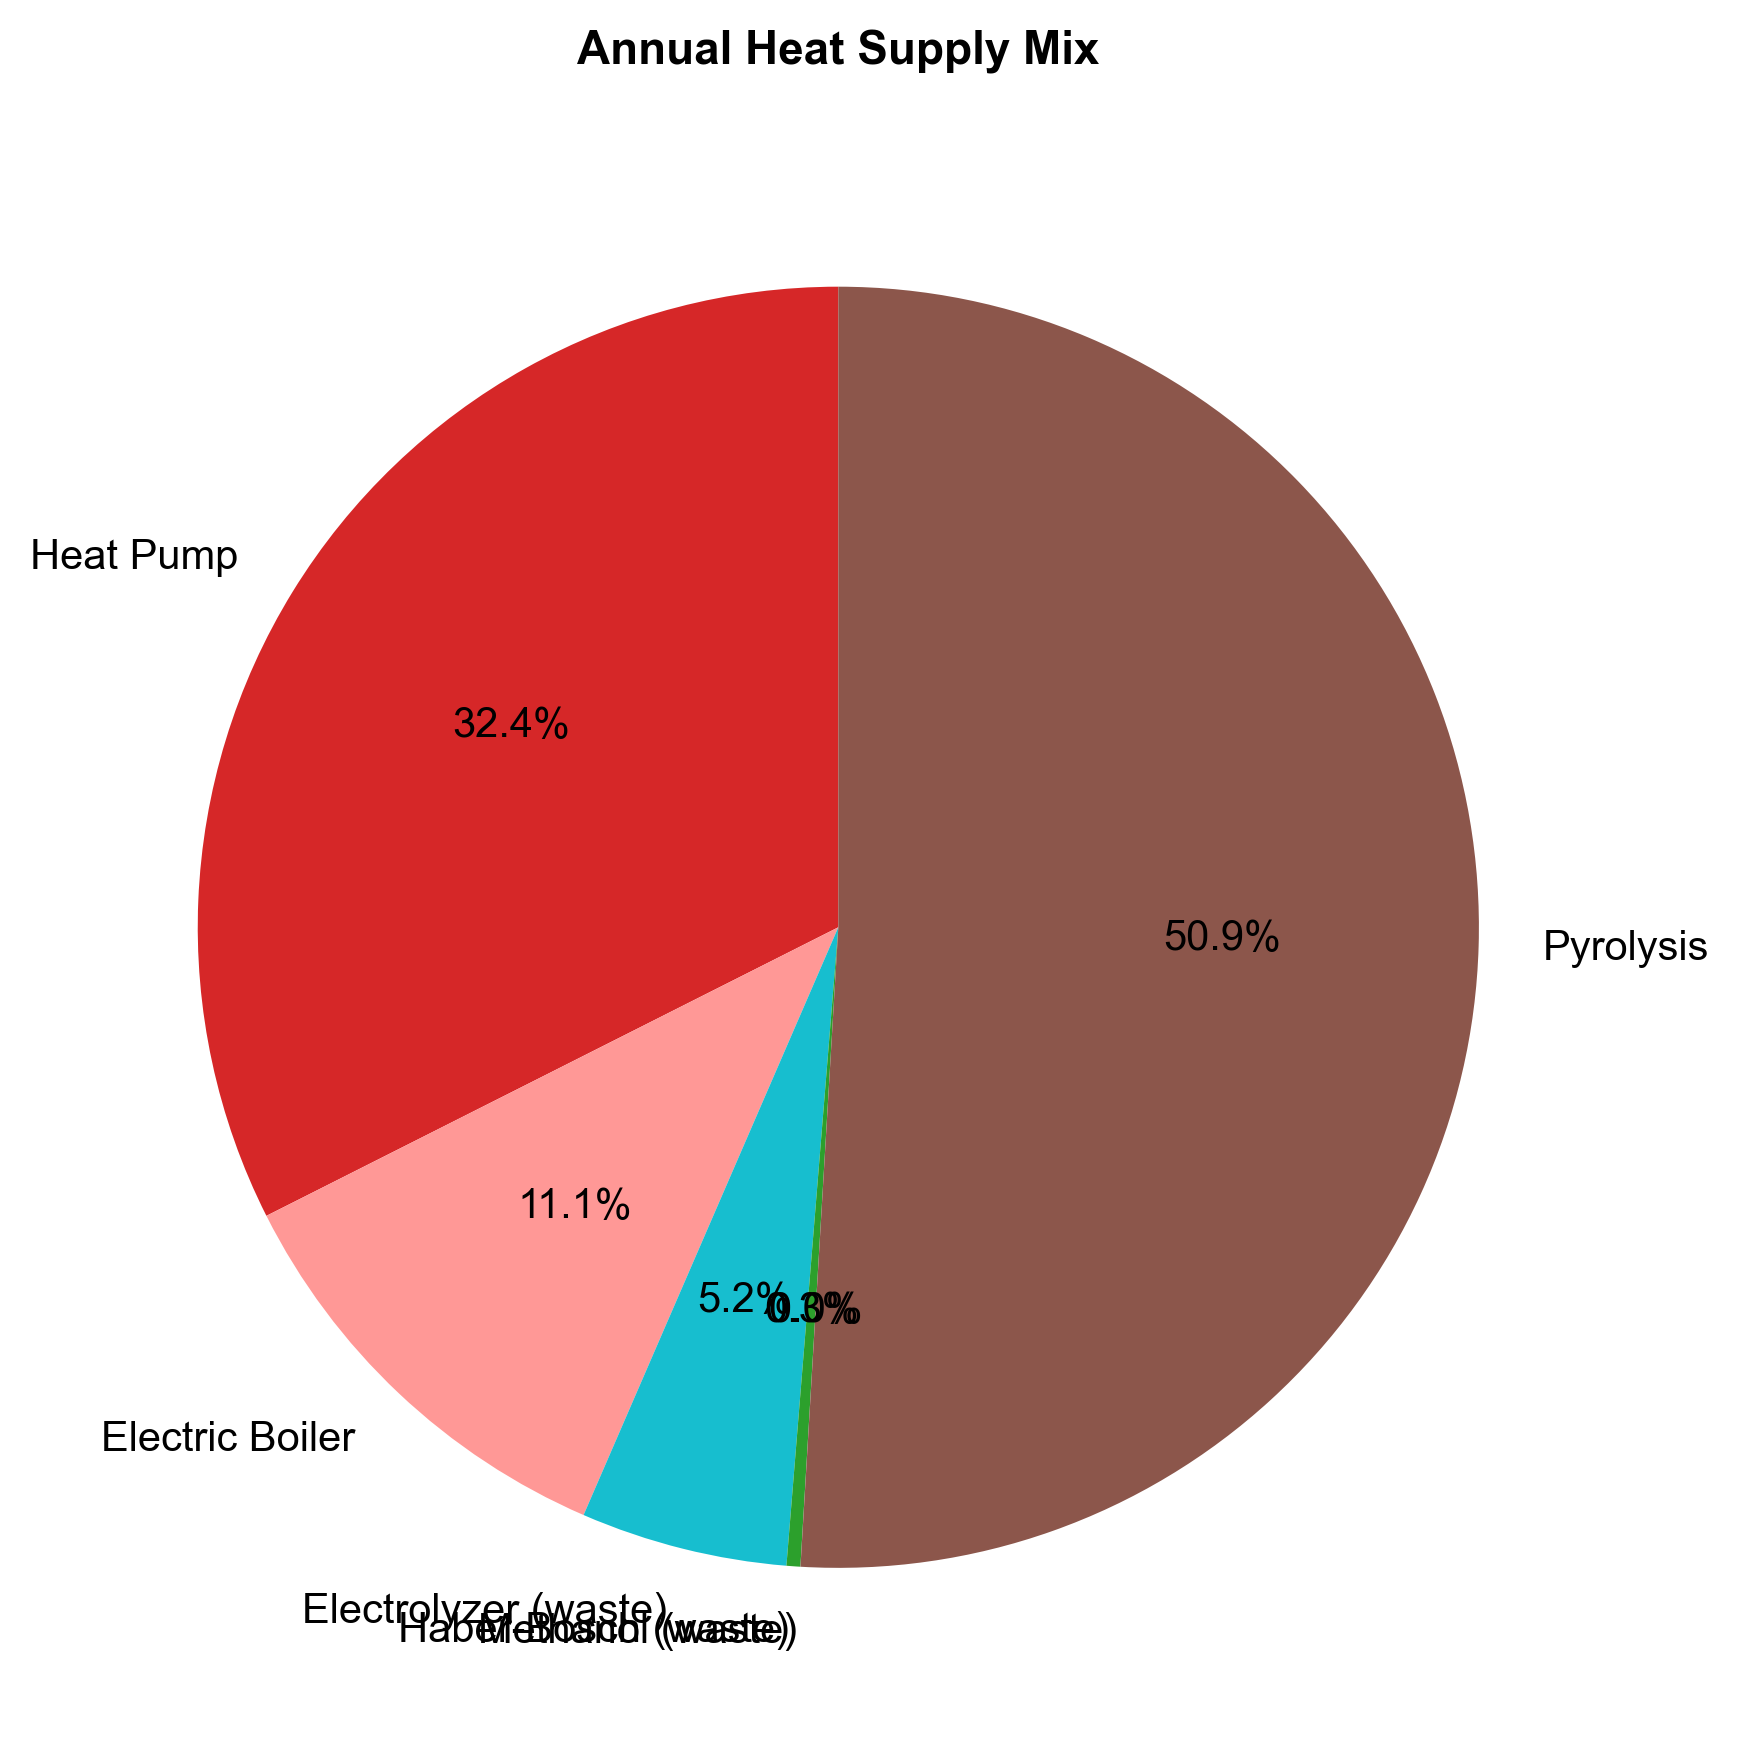

In [23]:
heat_from_hp = -n.links_t.p1['Heat_Pump'].sum()
heat_from_boiler = -n.links_t.p1['Electric_Boiler'].sum()
heat_from_electrolyzer = -n.links_t.p2['Electrolyzer'].sum()
heat_from_haber_bosch = -n.links_t.p3['Haber_Bosch'].sum()
heat_from_methanol = -n.links_t.p3['Methanol_Synthesis'].sum()
heat_from_pyrolysis = -n.links_t.p1['Pyrolysis'].sum()

total_heat_produced = (heat_from_hp + heat_from_boiler + heat_from_electrolyzer
                        + heat_from_haber_bosch + heat_from_methanol + heat_from_pyrolysis)
waste_heat_recovered = heat_from_electrolyzer + heat_from_haber_bosch + heat_from_methanol + heat_from_pyrolysis

biomass_processed_t = n.generators_t.p['Biomass_Feedstock'].sum()
biochar_produced_t = -n.links_t.p2['Pyrolysis'].sum()
heat_sold_mwh = -n.generators_t.p['Heat_Market'].sum()

print("Heat Supply Mix:")
print(f"  Heat Pump:              {heat_from_hp:>10,.2f} MWh ({100*heat_from_hp/total_heat_produced:.1f}%)")
print(f"  Electric Boiler:        {heat_from_boiler:>10,.2f} MWh ({100*heat_from_boiler/total_heat_produced:.1f}%)")
print(f"  Electrolyzer (waste):   {heat_from_electrolyzer:>10,.2f} MWh ({100*heat_from_electrolyzer/total_heat_produced:.1f}%)")
print(f"  Haber-Bosch (waste):    {heat_from_haber_bosch:>10,.2f} MWh ({100*heat_from_haber_bosch/total_heat_produced:.1f}%)")
print(f"  Methanol Synth (waste): {heat_from_methanol:>10,.2f} MWh ({100*heat_from_methanol/total_heat_produced:.1f}%)")
print(f"  Pyrolysis:              {heat_from_pyrolysis:>10,.2f} MWh ({100*heat_from_pyrolysis/total_heat_produced:.1f}%)")
print("-" * 50)
print(f"Total Heat Produced:        {total_heat_produced:,.2f} MWh")
print(f"  - of which recovered/waste-derived: {waste_heat_recovered:,.2f} MWh ({100*waste_heat_recovered/total_heat_produced:.1f}%)")
print(f"Heat Sold to External Market: {heat_sold_mwh:,.2f} MWh")
print("-" * 50)
print(f"Biomass Processed:          {biomass_processed_t:,.2f} t")
print(f"Biochar Produced:           {biochar_produced_t:,.2f} t")

# Pie chart of the annual heat supply mix
fig, ax = plt.subplots(figsize=(6, 6))
sources = ['Heat Pump', 'Electric Boiler', 'Electrolyzer (waste)', 'Haber-Bosch (waste)', 'Methanol (waste)', 'Pyrolysis']
values = [heat_from_hp, heat_from_boiler, heat_from_electrolyzer, heat_from_haber_bosch, heat_from_methanol, heat_from_pyrolysis]
colors = ['#d62728', '#ff9896', '#17becf', '#2ca02c', '#e377c2', '#8c564b']
ax.pie(values, labels=sources, colors=colors, autopct='%1.1f%%', startangle=90)
ax.set_title('Annual Heat Supply Mix', pad=15, fontweight='bold')
plt.tight_layout()
plt.show()


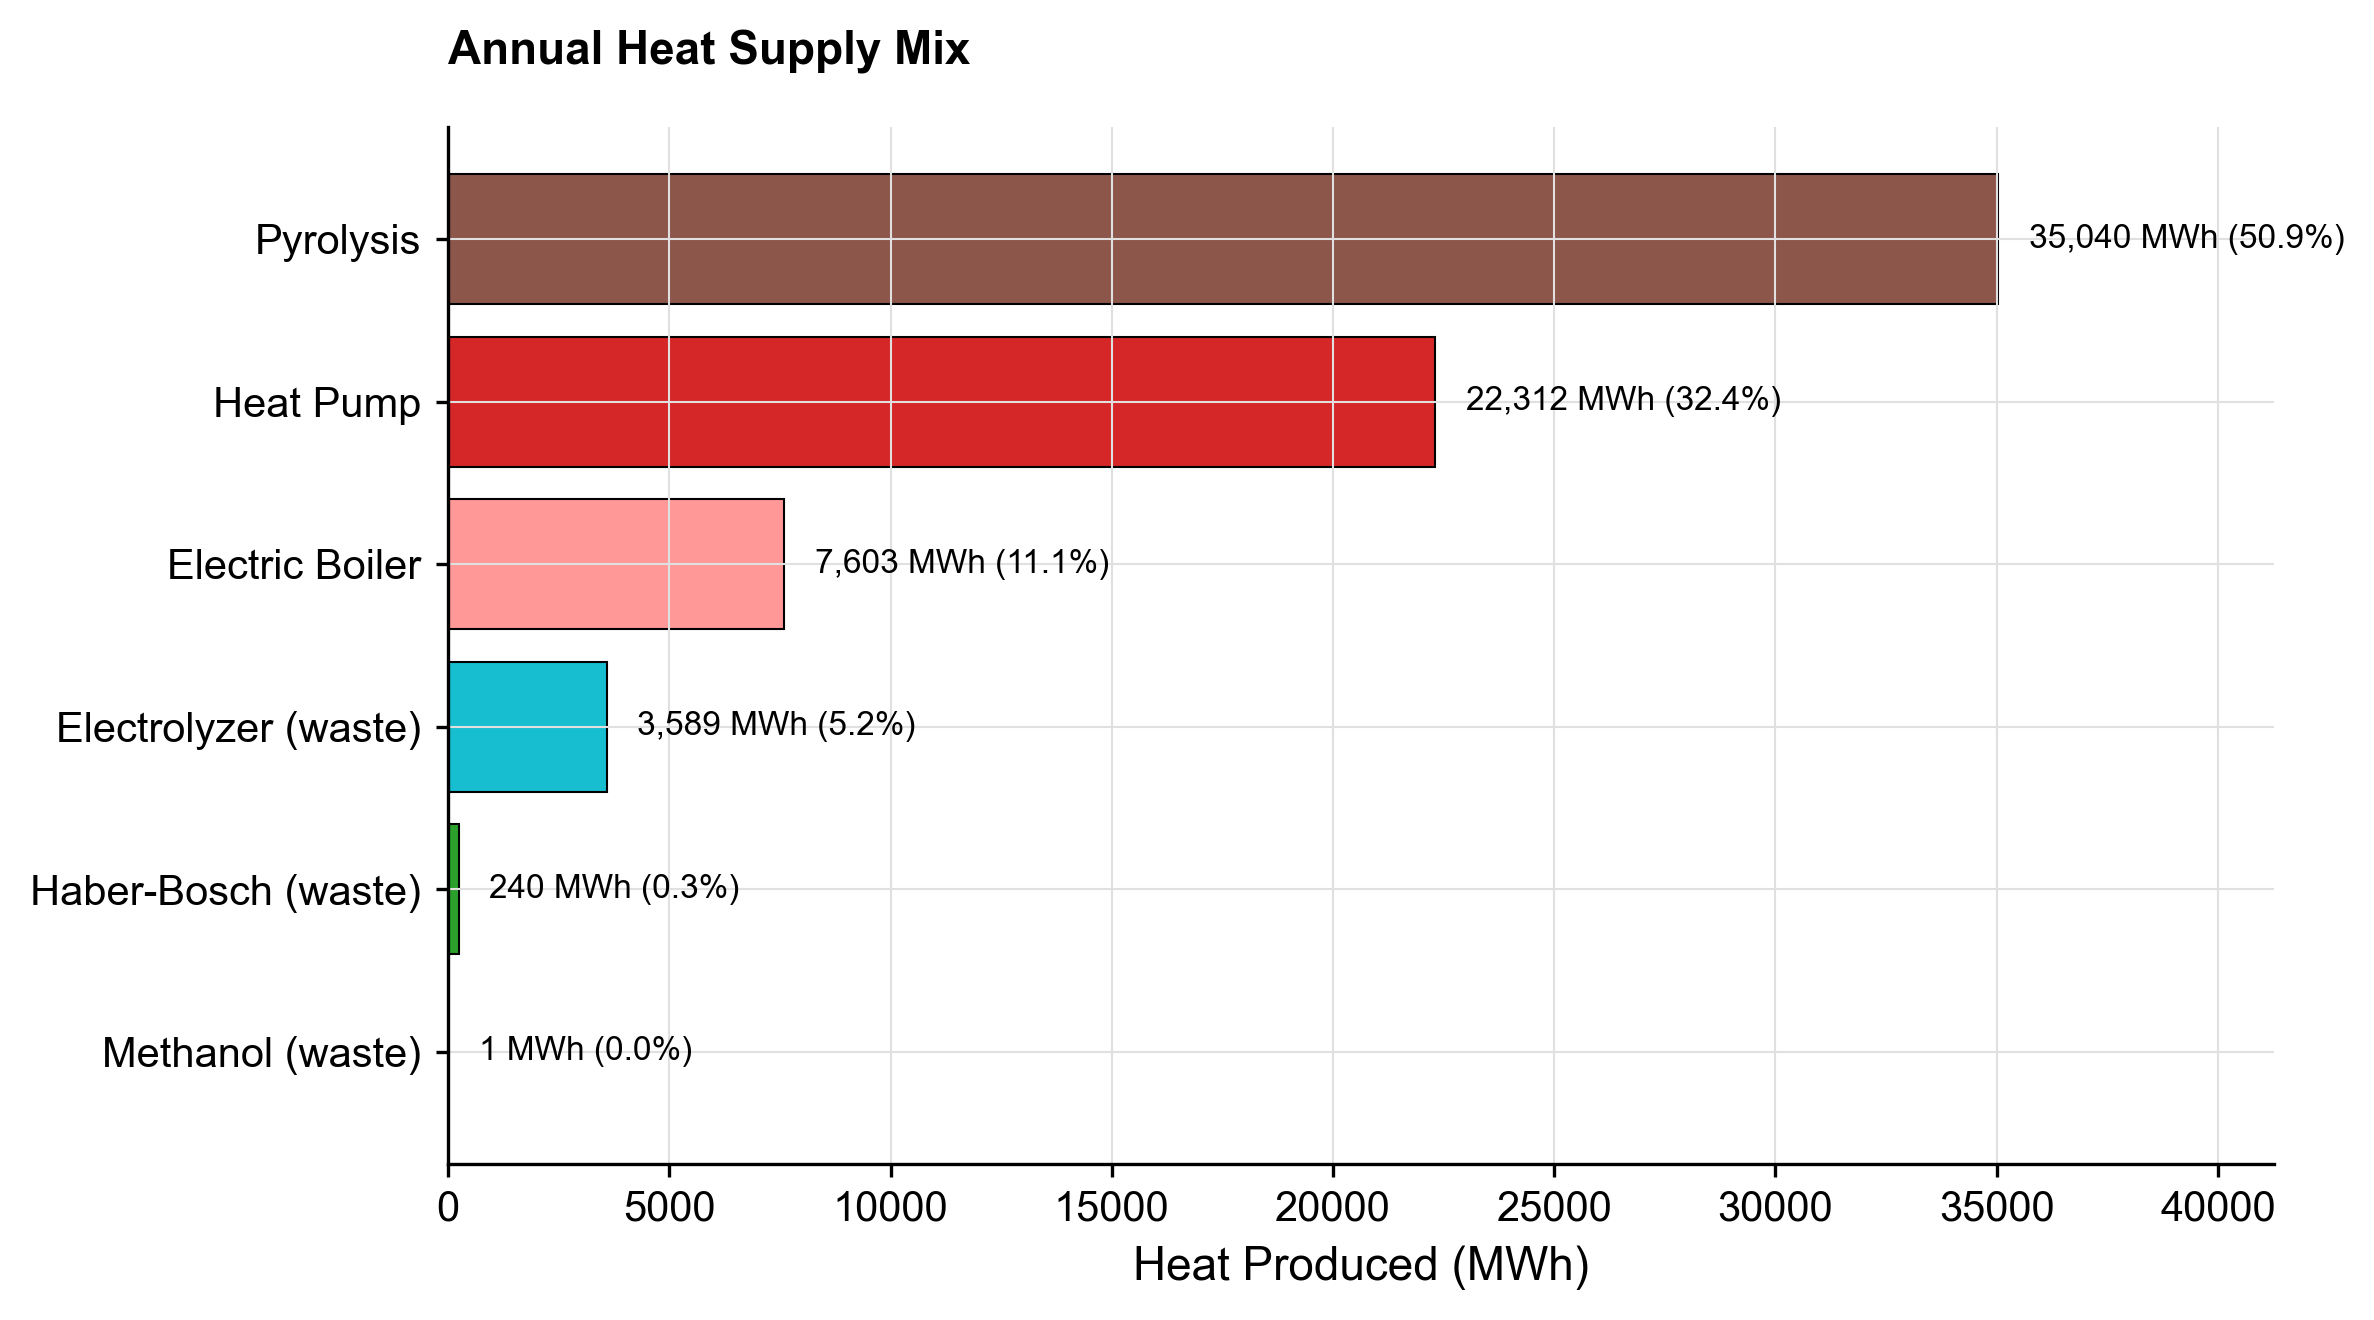

In [25]:
# Bar chart of the annual heat supply mix, sorted smallest to largest
sources = ['Heat Pump', 'Electric Boiler', 'Electrolyzer (waste)', 'Haber-Bosch (waste)', 'Methanol (waste)', 'Pyrolysis']
values = [heat_from_hp, heat_from_boiler, heat_from_electrolyzer, heat_from_haber_bosch, heat_from_methanol, heat_from_pyrolysis]
colors = ['#d62728', '#ff9896', '#17becf', '#2ca02c', '#e377c2', '#8c564b']

order = sorted(range(len(values)), key=lambda i: values[i])
sources = [sources[i] for i in order]
values = [values[i] for i in order]
colors = [colors[i] for i in order]

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.barh(sources, values, color=colors, edgecolor='black', linewidth=0.5)

for bar, val in zip(bars, values):
    pct = 100 * val / total_heat_produced
    label = f'{val:,.0f} MWh ({pct:.1f}%)'
    ax.text(bar.get_width() + total_heat_produced * 0.01, bar.get_y() + bar.get_height()/2,
            label, va='center', fontsize=8)

ax.set_xlabel('Heat Produced (MWh)')
ax.set_title('Annual Heat Supply Mix', pad=15, loc='left', fontweight='bold')
ax.set_xlim(0, total_heat_produced * 0.6)  # headroom so labels don't clip off the right edge
plt.tight_layout()
plt.show()